In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np

# -----------------------------
# 1️⃣ Define Features & Target
# -----------------------------

X = data[['lif2', 'lif1', 'lf', 'a', 'freq']]
y = data['s11']

print("Input shape:", X.shape)
print("Output shape:", y.shape)

# -----------------------------
# 2️⃣ Train-Test Split
# -----------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,     # 20% test
    random_state=42
)

print("\nTrain shape:", X_train.shape)
print("Test shape:", X_test.shape)

# -----------------------------
# 3️⃣ Scaling (VERY IMPORTANT)
# -----------------------------

scaler = StandardScaler()

# Fit only on training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data using same scaler
X_test_scaled = scaler.transform(X_test)

print("\nAfter Scaling:")
print("Scaled Train shape:", X_train_scaled.shape)
print("Scaled Test shape:", X_test_scaled.shape)

Input shape: (460460, 5)
Output shape: (460460,)

Train shape: (368368, 5)
Test shape: (92092, 5)

After Scaling:
Scaled Train shape: (368368, 5)
Scaled Test shape: (92092, 5)


In [ ]:
import pandas as pd
import numpy as np
from google.colab import files
import io

# 1️⃣ Load dataset
try:
    data = pd.read_csv('/content/Slot Triangle Dataset.csv')
except FileNotFoundError:
    print('Dataset not found. Please upload the "Slot Triangle Dataset.csv" file.')
    uploaded = files.upload()
    if uploaded:
        for fn in uploaded.keys():
            data = pd.read_csv(io.StringIO(uploaded[fn].decode('utf-8')))
            print(f'Successfully loaded {fn}')
    else:
        print('No file uploaded. Please upload the dataset to proceed.')
        # Exit or raise an error if no data is loaded
        raise SystemExit('Dataset not loaded.')

# 2️⃣ Rename columns to simple names (important for later)
data = data.rename(columns={
    'lif2 (inset feed length 2)': 'lif2',
    'lif1 (inset feed length 1)': 'lif1',
    'lf (feed length)': 'lf',
    'a (patch radius)': 'a',
    'S11': 's11'
})

# 3️⃣ Basic Info
print("Dataset Shape (rows, columns):")
print(data.shape)

print("\nColumn Names:")
print(data.columns)

print("\nData Types:")
print(data.dtypes)

print("\nNull Values:")
print(data.isnull().sum())

print("\nDuplicate Rows:")
print(data.duplicated().sum())

print("\nS11 Range:")
print("Min:", data['s11'].min())
print("Max:", data['s11'].max())

print("\nFrequency Range:")
print("Min:", data['freq'].min())
print("Max:", data['freq'].max())

Dataset Shape (rows, columns):
(460460, 6)

Column Names:
Index(['freq', 'lif2', 'lif1', 'lf', 'a', 's11'], dtype='object')

Data Types:
freq    float64
lif2      int64
lif1      int64
lf        int64
a       float64
s11     float64
dtype: object

Null Values:
freq    0
lif2    0
lif1    0
lf      0
a       0
s11     0
dtype: int64

Duplicate Rows:
0

S11 Range:
Min: -50.0172
Max: -0.753299

Frequency Range:
Min: 2.0
Max: 3.0


In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Build Model
model = keras.Sequential([
    layers.Dense(128, activation='relu', input_shape=(5,)),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(1)  # Output layer (S11)
])

# Compile Model
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

# Show Model Summary
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,601 (100.00 KB)

 Trainable params: 25,601 (100.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train_scaled, y_train,
    epochs=50,
    batch_size=1024,
    validation_split=0.2,
    verbose=1
)

Epoch 1/50
288/288 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 11.5840 - mae: 2.2187 - val_loss: 2.7603 - val_mae: 0.9547
Epoch 2/50
288/288 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 2.0487 - mae: 0.8360 - val_loss: 1.2067 - val_mae: 0.6464
Epoch 3/50
288/288 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - loss: 0.9940 - mae: 0.5767 - val_loss: 0.7108 - val_mae: 0.4639
Epoch 4/50
288/288 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.6436 - mae: 0.4535 - val_loss: 0.5007 - val_mae: 0.3887
Epoch 5/50
288/288 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.4908 - mae: 0.3887 - val_loss: 0.4167 - val_mae: 0.3689
Epoch 6/50
288/288 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.3821 - mae: 0.3416 - val_loss: 0.3301 - val_mae: 0.3092
Epoch 7/50
288/288 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 0.3212 - mae: 0.3120 - val_loss: 0.2655 - val_mae: 0.2778
Epoch 8/50
288/288 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.2752 - mae: 0.2910 - val_loss: 0.2673 - val_mae: 0.3092
Epoch 9/50
288/288 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/ste

In [ ]:
from sklearn.metrics import r2_score

y_pred = model.predict(X_test_scaled)
print("R2 Score:", r2_score(y_test, y_pred))

2878/2878 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step
R2 Score: 0.9952584345885881


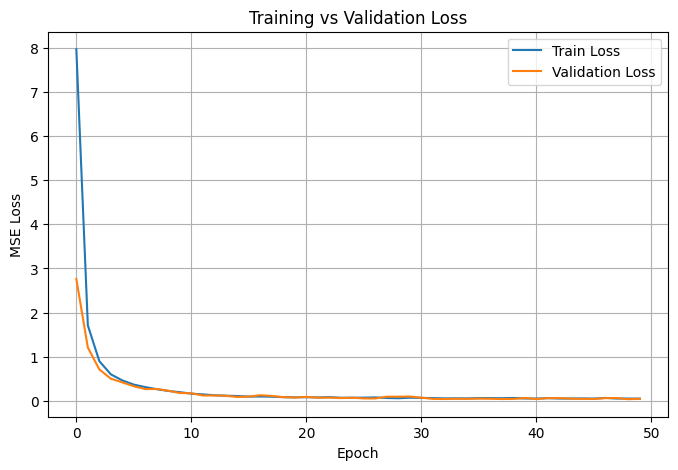

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

# Check if 'history' is defined before trying to plot
if 'history' in locals() or 'history' in globals():
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('MSE Loss')
    plt.title('Training vs Validation Loss')
    plt.legend()
    plt.grid()
else:
    plt.text(0.5, 0.5, "Error: 'history' not defined. Please run the model training cell (x82QV7aG5-XU) first.",
             horizontalalignment='center', verticalalignment='center', transform=plt.gca().transAxes, fontsize=12, color='red')
    plt.title('Plot Not Available')
    plt.xticks([])
    plt.yticks([])

plt.show()

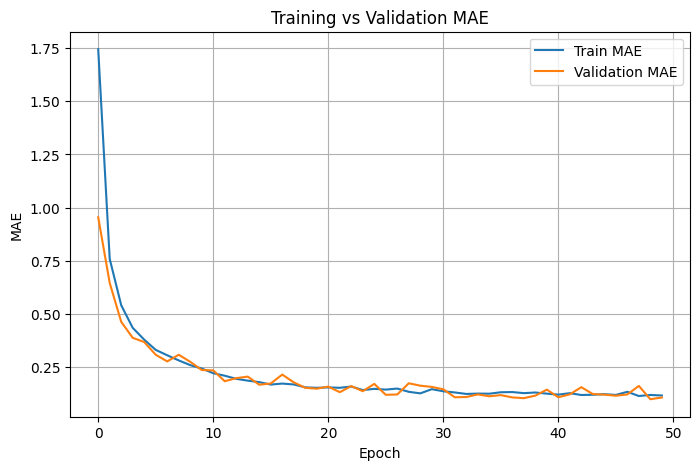

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.title('Training vs Validation MAE')
plt.legend()
plt.grid()
plt.show()

2878/2878 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step


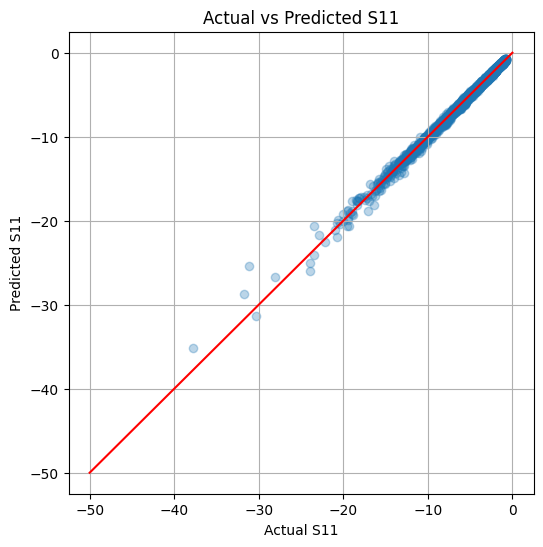

In [ ]:
y_pred = model.predict(X_test_scaled)

plt.figure(figsize=(6,6))
plt.scatter(y_test[:5000], y_pred[:5000], alpha=0.3)
plt.xlabel("Actual S11")
plt.ylabel("Predicted S11")
plt.title("Actual vs Predicted S11")
plt.plot([-50,0], [-50,0], 'r')  # Ideal line
plt.grid()
plt.show()

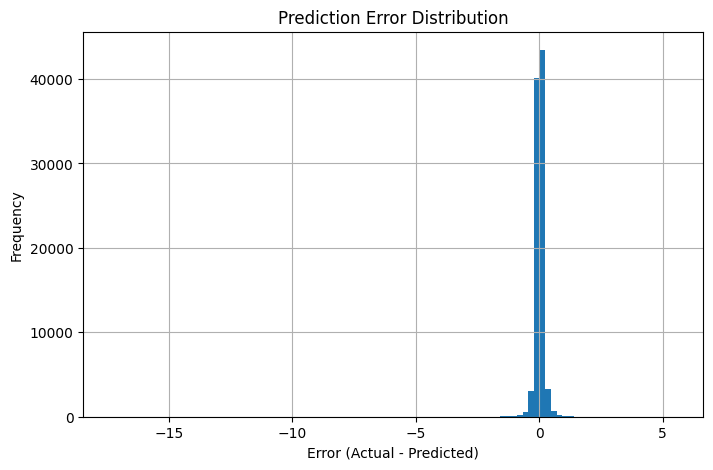

In [ ]:
errors = y_test - y_pred.flatten()

plt.figure(figsize=(8,5))
plt.hist(errors, bins=100)
plt.title("Prediction Error Distribution")
plt.xlabel("Error (Actual - Predicted)")
plt.ylabel("Frequency")
plt.grid()
plt.show()

In [ ]:
# Get geometry ranges from dataset

lif2_min, lif2_max = data['lif2'].min(), data['lif2'].max()
lif1_min, lif1_max = data['lif1'].min(), data['lif1'].max()
lf_min, lf_max = data['lf'].min(), data['lf'].max()
a_min, a_max = data['a'].min(), data['a'].max()

print("lif2 range:", lif2_min, "to", lif2_max)
print("lif1 range:", lif1_min, "to", lif1_max)
print("lf range:", lf_min, "to", lf_max)
print("a range:", a_min, "to", a_max)

lif2 range: 14 to 18
lif1 range: 18 to 21
lf range: 23 to 27
a range: 48.0 to 50.0


In [ ]:
# Recreate frequency grid (same as training)
freq_values = np.arange(2.0, 3.001, 0.01)

print("Total frequency points:", len(freq_values))

Total frequency points: 101


In [ ]:
# ==============================
# USER INPUT
# ==============================

target_freq = 2.4           # desired resonance frequency (GHz)
s11_threshold = -10         # required minimum dip (can change)
num_candidates = 1500       # number of random geometries to try


# ==============================
# OPTIMIZATION SEARCH
# ==============================

results = []

for _ in range(num_candidates):

    # Random geometry generation
    lif2_val = np.random.randint(lif2_min, lif2_max+1)
    lif1_val = np.random.randint(lif1_min, lif1_max+1)
    lf_val = np.random.randint(lf_min, lf_max+1)
    a_val = np.random.uniform(a_min, a_max)

    # Build full frequency sweep input
    X_curve = np.column_stack((
        np.full(len(freq_values), lif2_val),
        np.full(len(freq_values), lif1_val),
        np.full(len(freq_values), lf_val),
        np.full(len(freq_values), a_val),
        freq_values
    ))

    # Scale
    X_curve_scaled = scaler.transform(X_curve)

    # Predict S11 curve
    predicted_s11 = model.predict(X_curve_scaled, verbose=0).flatten()

    # Find minimum S11 (resonance)
    min_index = np.argmin(predicted_s11)
    res_freq = freq_values[min_index]
    min_s11 = predicted_s11[min_index]

    # Apply threshold condition
    if min_s11 < s11_threshold:
        freq_error = abs(res_freq - target_freq)
        results.append((freq_error, res_freq, min_s11,
                        lif2_val, lif1_val, lf_val, a_val))

# ==============================
# SORT & DISPLAY RESULTS
# ==============================

results.sort(key=lambda x: x[0])

print("\n===== TOP 3 DESIGN SUGGESTIONS =====\n")

if len(results) == 0:
    print("No design met the S11 threshold. Increase samples or relax threshold.")
else:
    for r in results[:3]:
        print(f"Resonant Freq : {r[1]:.3f} GHz")
        print(f"Minimum S11   : {r[2]:.2f} dB")
        print(f"lif2={r[3]}, lif1={r[4]}, lf={r[5]}, a={r[6]:.2f}")
        print("-------------------------------------------------")

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut


===== TOP 3 DESIGN SUGGESTIONS =====

Resonant Freq : 2.400 GHz
Minimum S11   : -14.36 dB
lif2=16, lif1=19, lf=27, a=48.02
-------------------------------------------------
Resonant Freq : 2.400 GHz
Minimum S11   : -14.32 dB
lif2=16, lif1=19, lf=27, a=48.05
-------------------------------------------------
Resonant Freq : 2.390 GHz
Minimum S11   : -23.31 dB
lif2=14, lif1=18, lf=25, a=48.04
-------------------------------------------------


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
# Save trained model
model.save("antenna_forward_model.h5")

# Save scaler
import joblib
joblib.dump(scaler, "scaler.save")

print("Saved successfully.")

Saved successfully.
